In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dataclasses import dataclass
from typing import Dict, Tuple, List

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.neighbors import KNeighborsRegressor


In [18]:
AXES = [
    ("performance", "performance_score"),
    ("size", "size_score"),
    ("economy", "economy_score"),
    ("practicality", "practicality_score"),
    ("exoticness", "exoticness_score"),
    ("engagement", "engagement_score"),
]
FEATS = [feat for _, feat in AXES]
N_AXES = len(AXES)


In [19]:
vehicles = pd.read_csv("app/vehicles_features.csv")
vehicles = vehicles.dropna(subset=FEATS).reset_index(drop=True)
vehicles.head()


,vehicle_id,vehicle_name,production_year,performance_score,size_score,economy_score,practicality_score,exoticness_score,engagement_score
0,1,Audi Q3 III Sportback-e 1.5 45 TFSI e-hybrid 2...,2025.0,0.702990,0.670673,-3.009082,-0.378690,-0.420631,-1.918331
1,2,Audi Q3 III SUV 2.0 35 TDI 150KM 110kW od 2025,2025.0,0.224175,0.533317,-0.479175,0.040701,-0.420631,-1.335011
2,3,Audi Q5 III Sportback-e 2.0 55 TFSI e-hybrid 3...,2025.0,1.522641,1.341766,-2.033786,-0.155511,-0.420631,-0.751691
3,4,Audi Q5 III Sportback 2.0 40 TDI 204KM 150kW o...,2025.0,0.675689,1.196651,-0.094039,0.120869,-0.420631,-0.168371
4,5,Audi Q5 III Sportback 2.0 40 TFSI Mild Hybrid ...,2025.0,0.565942,1.146164,0.347215,0.120869,-0.420631,-0.751691


In [20]:
vehicles[FEATS].describe()


,performance_score,size_score,economy_score,practicality_score,exoticness_score,engagement_score
count,24546.000000,2.454600e+04,2.454600e+04,2.454600e+04,2.454600e+04,2.454600e+04
mean,0.000000,-2.315792e-17,-9.263166e-18,4.110530e-17,-7.410533e-17,4.052635e-17
std,1.000020,1.000020e+00,1.000020e+00,1.000020e+00,1.000020e+00,1.000020e+00
min,-4.226615,-4.342544e+00,-4.463692e+00,-2.219436e+00,-4.206308e-01,-3.318299e+00
25%,-0.670837,-6.618228e-01,-5.404609e-01,-3.313568e-01,-4.206308e-01,-1.683705e-01
50%,-0.192293,-4.946617e-02,9.641937e-02,-8.579738e-02,-4.206308e-01,6.495752e-02
75%,0.492472,5.629718e-01,4.247122e-01,1.047048e-01,-4.206308e-01,1.816215e-01
max,5.681952,7.645423e+00,8.475837e+00,2.484514e+01,5.461704e+00,2.514902e+00


In [21]:
def ndcg_at_k(relevances: np.ndarray, k: int) -> float:
    k = min(k, len(relevances))
    if k == 0:
        return 0.0
    rel = relevances[:k]
    dcg = np.sum((2**rel - 1) / np.log2(np.arange(2, k + 2)))

    ideal = np.sort(relevances)[::-1][:k]
    idcg = np.sum((2**ideal - 1) / np.log2(np.arange(2, k + 2)))
    return float(dcg / idcg) if idcg > 0 else 0.0


def precision_at_k(is_relevant: np.ndarray, k: int) -> float:
    k = min(k, len(is_relevant))
    if k == 0:
        return 0.0
    return float(np.mean(is_relevant[:k]))


def topk_jaccard(a: List[int], b: List[int], k: int) -> float:
    sa = set(a[:k])
    sb = set(b[:k])
    if not sa and not sb:
        return 1.0
    return float(len(sa & sb) / len(sa | sb))


In [22]:
@dataclass
class SyntheticUser:
    rated_indices: np.ndarray
    ratings: np.ndarray
    true_p: np.ndarray


In [23]:
def generate_synthetic_user(
    X: np.ndarray,
    n_rated_range: Tuple[int,int] = (5, 10),
    neutral_rate: float = 0.6,
    noise_std: float = 0.10,
    rng: np.random.Generator | None = None,
) -> SyntheticUser:
    if rng is None:
        rng = np.random.default_rng(0)

    n = X.shape[0]
    n_rated = rng.integers(n_rated_range[0], n_rated_range[1] + 1)


    scaler = StandardScaler()
    Xn = scaler.fit_transform(X)


    p = rng.normal(0, 1, size=(N_AXES,))
    p = p / (np.linalg.norm(p) + 1e-12)

    rated_idx = rng.choice(n, size=n_rated, replace=False)
    rated_Xn = Xn[rated_idx]


    prefs = np.zeros((n_rated, N_AXES), dtype=float)

    for i in range(n_rated):
        for j in range(N_AXES):
            if rng.random() < neutral_rate:
                prefs[i, j] = 0.0
            else:
                base = np.tanh(p[j] * rated_Xn[i, j])
                prefs[i, j] = base + rng.normal(0, noise_std)

    prefs = np.clip(prefs, -1, 1)
    return SyntheticUser(rated_indices=rated_idx, ratings=prefs, true_p=p)


In [24]:
def ground_truth_relevance(
    X: np.ndarray,
    true_p: np.ndarray,
    rng: np.random.Generator | None = None,
    noise_std: float = 0.0,
) -> np.ndarray:

    scaler = StandardScaler()
    Xn = scaler.fit_transform(X)
    rel = Xn @ true_p
    if noise_std > 0:
        if rng is None:
            rng = np.random.default_rng(0)
        rel = rel + rng.normal(0, noise_std, size=rel.shape)
    return rel


In [25]:
def score_ridge_multioutput(X_rated, Y_rated, X_candidates, alpha=1.0):
    sc = StandardScaler()
    Xs = sc.fit_transform(X_rated)
    Xc = sc.transform(X_candidates)

    model = Ridge(alpha=float(alpha), random_state=0)
    model.fit(Xs, Y_rated)

    Yhat = model.predict(Xc)
    scores = np.sum(Yhat, axis=1)
    return scores


In [26]:
def score_rank_pairwise(X_rated, Y_rated, X_candidates, C=1.0, min_pairs=6):
    q = np.mean(Y_rated, axis=1)

    sc = StandardScaler()
    Xs = sc.fit_transform(X_rated)
    Xc = sc.transform(X_candidates)

    Z_list, y_list = [], []
    n = Xs.shape[0]
    for i in range(n):
        for j in range(n):
            if q[i] > q[j] + 1e-9:
                z = Xs[i] - Xs[j]
                Z_list.append(z);  y_list.append(1)
                Z_list.append(-z); y_list.append(0)

    if len(y_list) < min_pairs:

        raise ValueError("Not enough ranking pairs")

    Z = np.asarray(Z_list, dtype=float)
    y = np.asarray(y_list, dtype=int)

    clf = LogisticRegression(C=float(C), solver="liblinear", random_state=0)
    clf.fit(Z, y)

    w = clf.coef_.reshape(-1)
    scores = Xc @ w
    return scores


In [27]:
def score_knn_multioutput(X_rated, Y_rated, X_candidates, n_neighbors=3):
    sc = StandardScaler()
    Xs = sc.fit_transform(X_rated)
    Xc = sc.transform(X_candidates)

    k = int(max(1, min(n_neighbors, Xs.shape[0])))
    knn = KNeighborsRegressor(n_neighbors=k, weights="distance")
    knn.fit(Xs, Y_rated)

    Yhat = knn.predict(Xc)
    scores = np.sum(Yhat, axis=1)
    return scores


In [28]:
def evaluate_once(
    X: np.ndarray,
    vehicles_df: pd.DataFrame,
    neutral_rate: float,
    rng: np.random.Generator,
    k_eval: int = 10,
):
    user = generate_synthetic_user(X, neutral_rate=neutral_rate, rng=rng)
    rel = ground_truth_relevance(X, user.true_p)

    rated = user.rated_indices
    candidates = np.setdiff1d(np.arange(X.shape[0]), rated)

    X_rated = X[rated]
    Y_rated = user.ratings
    X_cand = X[candidates]

    rel_cand = rel[candidates]

    gt_top = candidates[np.argsort(rel_cand)[::-1][:k_eval]]
    gt_set = set(gt_top.tolist())

    def run_algo(name: str):
        if name == "ridge":
            s = score_ridge_multioutput(X_rated, Y_rated, X_cand, alpha=1.0)
        elif name == "rank":
            try:
                s = score_rank_pairwise(X_rated, Y_rated, X_cand, C=1.0, min_pairs=6)
            except ValueError:
                s = score_ridge_multioutput(X_rated, Y_rated, X_cand, alpha=1.0)
        elif name == "knn":
            s = score_knn_multioutput(X_rated, Y_rated, X_cand, n_neighbors=3)
        else:
            raise ValueError(name)

        order = np.argsort(s)[::-1]
        ranked_ids = candidates[order]
        ranked_rel = rel[ranked_ids]


        rr = ranked_rel.copy()
        q1, q2 = np.quantile(rel_cand, [0.66, 0.90])
        disc_rel = np.where(rr >= q2, 3, np.where(rr >= q1, 1, 0))

        is_rel = np.array([1 if vid in gt_set else 0 for vid in ranked_ids], dtype=int)

        return {
            "top_ids": ranked_ids.tolist(),
            "ndcg": ndcg_at_k(disc_rel, k_eval),
            "prec": precision_at_k(is_rel, k_eval),
        }

    res_ridge = run_algo("ridge")
    res_rank  = run_algo("rank")
    res_knn   = run_algo("knn")

    if len(candidates) > 0:
        new_rated = np.append(rated, rng.choice(candidates, size=1, replace=False))

        extra_user = generate_synthetic_user(X, n_rated_range=(len(new_rated), len(new_rated)), neutral_rate=neutral_rate, rng=rng)
        extra_user = SyntheticUser(rated_indices=new_rated, ratings=extra_user.ratings, true_p=user.true_p)

        rated2 = extra_user.rated_indices
        cand2 = np.setdiff1d(np.arange(X.shape[0]), rated2)

        X_rated2 = X[rated2]
        Y_rated2 = extra_user.ratings
        X_cand2 = X[cand2]

        def get_top(name: str):
            if name == "ridge":
                s = score_ridge_multioutput(X_rated2, Y_rated2, X_cand2)
            elif name == "rank":
                try:
                    s = score_rank_pairwise(X_rated2, Y_rated2, X_cand2)
                except ValueError:
                    s = score_ridge_multioutput(X_rated2, Y_rated2, X_cand2)
            elif name == "knn":
                s = score_knn_multioutput(X_rated2, Y_rated2, X_cand2)
            order = np.argsort(s)[::-1]
            return cand2[order].tolist()

        stab_ridge = topk_jaccard(res_ridge["top_ids"], get_top("ridge"), k_eval)
        stab_rank  = topk_jaccard(res_rank["top_ids"],  get_top("rank"),  k_eval)
        stab_knn   = topk_jaccard(res_knn["top_ids"],   get_top("knn"),   k_eval)
    else:
        stab_ridge = stab_rank = stab_knn = 1.0

    return {
        "ridge_ndcg": res_ridge["ndcg"],
        "rank_ndcg": res_rank["ndcg"],
        "knn_ndcg": res_knn["ndcg"],
        "ridge_prec": res_ridge["prec"],
        "rank_prec": res_rank["prec"],
        "knn_prec": res_knn["prec"],
        "ridge_stab": stab_ridge,
        "rank_stab": stab_rank,
        "knn_stab": stab_knn,
    }


In [29]:
X = vehicles[FEATS].to_numpy(dtype=float)

def run_experiment(neutral_rate: float, n_users: int = 500, seed: int = 42):
    rng = np.random.default_rng(seed)
    rows = []
    for _ in range(n_users):
        rows.append(evaluate_once(X, vehicles, neutral_rate=neutral_rate, rng=rng, k_eval=10))
    return pd.DataFrame(rows)

neutral_grid = [0.5, 0.6, 0.7, 0.8, 0.9]

dfs = {}
for nr in neutral_grid:
    dfs[nr] = run_experiment(neutral_rate=nr, n_users=400, seed=int(nr * 1000))




In [30]:
def summarize(df: pd.DataFrame, label: str):
    return pd.DataFrame({
        "setting": [label],
        "ridge_ndcg": [df["ridge_ndcg"].mean()],
        "rank_ndcg": [df["rank_ndcg"].mean()],
        "knn_ndcg": [df["knn_ndcg"].mean()],
        "ridge_stab": [df["ridge_stab"].mean()],
        "rank_stab": [df["rank_stab"].mean()],
        "knn_stab": [df["knn_stab"].mean()],
    })

sum_df = pd.concat(
    [summarize(dfs[nr], f"neutral={nr:.2f}") for nr in neutral_grid],
    ignore_index=True
)

sum_df



,setting,ridge_ndcg,rank_ndcg,knn_ndcg,ridge_stab,rank_stab,knn_stab
0,neutral=0.50,0.690268,0.645118,0.381980,0.082263,0.093364,0.043871
1,neutral=0.60,0.652621,0.624939,0.363597,0.078405,0.082307,0.048073
2,neutral=0.70,0.635736,0.599544,0.325616,0.070154,0.078753,0.034912
3,neutral=0.80,0.569327,0.517086,0.316076,0.063089,0.067515,0.059501
4,neutral=0.90,0.507776,0.484989,0.253041,0.089341,0.094830,0.052355


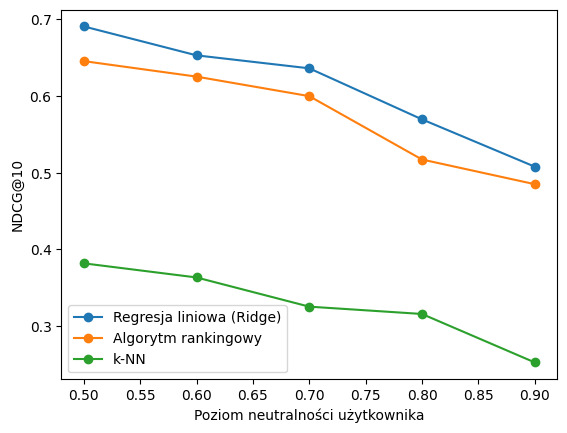

In [34]:
sum_df["neutral"] = [float(s.split("=")[1]) for s in sum_df["setting"]]

plt.figure()
plt.plot(sum_df["neutral"], sum_df["ridge_ndcg"], marker="o", label="Regresja liniowa (Ridge)")
plt.plot(sum_df["neutral"], sum_df["rank_ndcg"], marker="o", label="Algorytm rankingowy")
plt.plot(sum_df["neutral"], sum_df["knn_ndcg"], marker="o", label="k-NN")
plt.xlabel("Poziom neutralności użytkownika")
plt.ylabel("NDCG@10")
plt.legend()
plt.show()



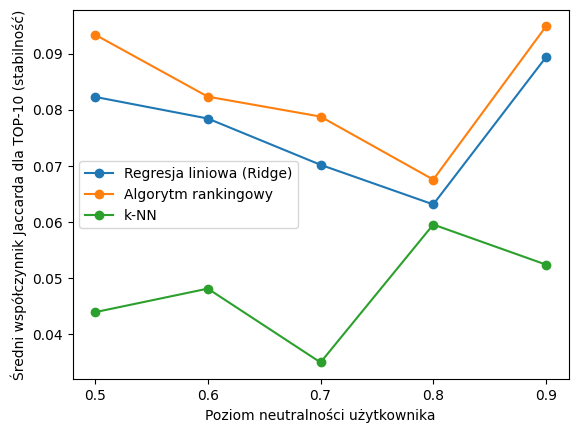

In [35]:
plt.figure()
plt.plot(sum_df["neutral"], sum_df["ridge_stab"], marker="o", label="Regresja liniowa (Ridge)")
plt.plot(sum_df["neutral"], sum_df["rank_stab"], marker="o", label="Algorytm rankingowy")
plt.plot(sum_df["neutral"], sum_df["knn_stab"], marker="o", label="k-NN")
plt.ylabel("Średni współczynnik Jaccarda dla TOP-10 (stabilność)")
plt.xlabel("Poziom neutralności użytkownika")
plt.xticks(sum_df["neutral"])
plt.legend()
plt.show()

